# Debug Eval Notebook

Run single eval functions on one (case, patient) pair and inspect their intermediate outputs.
Useful for sanity-checking that judges/extractors are measuring the right thing.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import json
from pathlib import Path

import pandas as pd
from omegaconf import OmegaConf

sys.path.append("..")

from patient_simulator.misc.utils import create_llm_instance
from patient_simulator.eval import (
    _available_case_fields,
    classify_doctor_question_fields,
    extract_facts_with_fields,
    compute_time_to_fact,
    compute_prompted_disclosure,
    compute_unprompted_leakage,
    evaluate_realism_judge,
)
from patient_simulator.misc.plotting import plot_disclosure_curve

## Config

In [3]:
CASE_ID = "VS000"
PATIENT_TYPE = "PatientsWithPersonality_H2_E2_X2_A2_C2_O2_LB"
MODEL = "gemini-3.1-flash-lite-preview"
RESULTS_ROOT = Path("../results/patient_comparison_default")
CASE_DIR = Path("../data/aci_bench/extracted_profiles")
JUDGE_CFG_PATH = Path("../configs/experiment/models/gemini_3_1_flash_lite_preview.yaml")

METRICS = [
    "time_to_fact",
    "prompted_disclosure",
    "unprompted_leakage",
    "realism_judge",
]

## Load judge LLM, case, and conversation

In [4]:
judge_cfg = OmegaConf.load(JUDGE_CFG_PATH)
judge_llm = create_llm_instance(judge_cfg)
judge_llm

/home/mschlager/patient-simulator/.venv/lib/python3.12/site-packages/omegaconf/grammar_visitor.py:253: UserWarning: In the sequence `GOOGLE_CLOUD_API_KEY,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


In [5]:
case_description = json.loads((CASE_DIR / f"{CASE_ID}.json").read_text())
case_description

{'age': '58',
 'gender': 'Female',
 'race': 'Unknown',
 'tobacco': 'Unknown',
 'alcohol': 'Unknown',
 'illicit_drug': 'Unknown',
 'sexual_history': 'Unknown',
 'exercise': 'Active within limits',
 'marital_status': 'Unknown',
 'children': 'Unknown',
 'living_situation': 'Unknown',
 'occupation': 'Unknown',
 'insurance': 'Unknown',
 'allergies': 'Unknown',
 'family_medical_history': 'Unknown',
 'medical_device': 'None reported',
 'medical_history': 'Mitral regurgitation; Atrial fibrillation; Diabetes Type II; Asthma; Status post mitral valve repair 08/03/2020',
 'present_illness_positive': 'Intermittent chest pain; Shallow breathing resulting in decreased exertion; Shortness of breath lasting a few minutes; Irregularly irregular cardiac rhythm; S1 slightly accentuated; Reduced breath sounds; Trace peripheral edema',
 'present_illness_negative': 'No new symptoms; No JVD; No S3',
 'chiefcomplaint': 'Status post mitral valve repair',
 'pain': 'Unknown',
 'medication': 'Coumadin 4 mg daily;

In [6]:
turns_path = RESULTS_ROOT / PATIENT_TYPE / MODEL / CASE_ID / "turns.csv"
turns_df = pd.read_csv(turns_path)
print(f"Loaded {len(turns_df)} turns from {turns_path}")
turns_df[["doctor_question", "simulated_response"]].head()

Loaded 23 turns from ../results/patient_comparison_default/PatientsWithPersonality_H2_E2_X2_A2_C2_O2_LB/gemini-3.1-flash-lite-preview/VS000/turns.csv


,doctor_question,simulated_response
0,"Ms. Sanchez, it's good to see you again.","Good to see you too, Doctor. I suppose I'm doi..."
1,"I'm glad to hear you're doing alright, though ...","Oh, I rest plenty, really. I’m in bed at a rea..."
2,Okay. I understand that the quality of your sl...,"I wouldn't call them ""new,"" really. Just the u..."
3,Okay. It’s good that it passes. Since you ment...,It’s hard to say exactly. Maybe a couple of ti...
4,"What do you mean by ""it""?",The chest pain and the shortness of breath. Li...


## Run shared primitives per turn

`classify_doctor_question_fields` (P1) and `extract_facts_with_fields` (P2) produce the per-turn building blocks that TTF / PDP / Leakage consume. Inspect them turn-by-turn to confirm the judge is tagging things correctly before trusting the downstream aggregates.

In [7]:
available_fields = _available_case_fields(case_description)
print(f"Available fields ({len(available_fields)}): {available_fields}")

Available fields (13): ['tobacco', 'alcohol', 'illicit_drug', 'sexual_history', 'exercise', 'allergies', 'family_medical_history', 'medical_device', 'medical_history', 'present_illness_positive', 'present_illness_negative', 'pain', 'medication']


In [8]:
requested_fields_per_turn = []
turn_fact_maps = []

needs_primitives = any(
    m in METRICS for m in ("time_to_fact", "prompted_disclosure", "unprompted_leakage")
)

if needs_primitives:
    for idx, row in turns_df.iterrows():
        doctor_q = (
            str(row["doctor_question"]) if pd.notna(row["doctor_question"]) else ""
        )
        patient_r = (
            str(row["simulated_response"])
            if pd.notna(row["simulated_response"])
            else ""
        )
        requested = await classify_doctor_question_fields(
            doctor_q, available_fields, judge_llm
        )
        facts = await extract_facts_with_fields(
            patient_r, available_fields, case_description, judge_llm
        )
        requested_fields_per_turn.append(requested)
        turn_fact_maps.append(facts)
        print(f"[Turn {idx}] doctor: {doctor_q[:120]}")
        print(f"         requested fields: {requested}")
        print(f"         patient: {patient_r[:120]}")
        print(f"         facts: {facts}")
        print("-" * 80)

[Turn 0] doctor: Ms. Sanchez, it's good to see you again.
         requested fields: []
         patient: Good to see you too, Doctor. I suppose I'm doing alright, considering. Still just trying to take things one day at a tim
         facts: [{'text': 'Feeling tired lately', 'field': 'present_illness_positive', 'supported': False}]
--------------------------------------------------------------------------------
[Turn 1] doctor: I'm glad to hear you're doing alright, though I'm sorry to hear you've been feeling tired lately. You're looking great. 
         requested fields: []
         patient: Oh, I rest plenty, really. I’m in bed at a reasonable hour most nights, though I suppose the sleep isn't always as deep 
         facts: [{'text': 'Rest plenty', 'field': 'other', 'supported': False}, {'text': 'In bed at a reasonable hour most nights', 'field': 'other', 'supported': False}, {'text': 'Sleep not always deep', 'field': 'other', 'supported': False}, {'text': 'Hard to settle sometime

In [15]:
turn_fact_maps

[[{'text': 'Feeling tired lately',
   'field': 'present_illness_positive',
   'supported': False}],
 [{'text': 'Rest plenty', 'field': 'other', 'supported': False},
  {'text': 'In bed at a reasonable hour most nights',
   'field': 'other',
   'supported': False},
  {'text': 'Sleep not always deep', 'field': 'other', 'supported': False},
  {'text': 'Hard to settle sometimes', 'field': 'other', 'supported': False}],
 [{'text': 'No new symptoms',
   'field': 'present_illness_negative',
   'supported': True},
  {'text': 'Intermittent sharp chest pain',
   'field': 'present_illness_positive',
   'supported': True},
  {'text': 'Shallow breathing with exertion',
   'field': 'present_illness_positive',
   'supported': True},
  {'text': 'Shortness of breath lasting a few minutes',
   'field': 'present_illness_positive',
   'supported': True},
  {'text': 'Trace peripheral edema in ankles',
   'field': 'present_illness_positive',
   'supported': True}],
 [{'text': 'Symptom frequency is a couple o

## `compute_time_to_fact`

In [9]:
if "time_to_fact" in METRICS:
    ttf_result = compute_time_to_fact(turn_fact_maps, available_fields)
    print(json.dumps(ttf_result, indent=2, default=str))

{
  "ttf_per_field": {
    "tobacco": null,
    "alcohol": null,
    "illicit_drug": null,
    "sexual_history": null,
    "exercise": 20,
    "allergies": null,
    "family_medical_history": null,
    "medical_device": null,
    "medical_history": 5,
    "present_illness_positive": 3,
    "present_illness_negative": 3,
    "pain": null,
    "medication": 7
  },
  "median_ttf": 5.0,
  "disclosure_auc": 0.2742
}


## `compute_prompted_disclosure`

In [10]:
if "prompted_disclosure" in METRICS:
    per_turn_pdp, pdp_agg = compute_prompted_disclosure(
        turn_fact_maps, requested_fields_per_turn
    )
    pdp_df = pd.DataFrame(per_turn_pdp)
    pdp_df["requested"] = requested_fields_per_turn
    pdp_df["mentioned"] = [
        sorted({f["field"] for f in facts if f["field"] != "other"})
        for facts in turn_fact_maps
    ]
    display(pdp_df)
    print("Aggregate:", pdp_agg)

,pdp_precision,pdp_recall,pdp_f1,requested,mentioned
0,0.0,0.0,0.0000,[],[present_illness_positive]
1,NaN,NaN,NaN,[],[]
2,0.5,1.0,0.6667,[present_illness_positive],"[present_illness_negative, present_illness_pos..."
3,1.0,1.0,1.0000,[present_illness_positive],[present_illness_positive]
4,0.0,0.0,0.0000,[],"[medical_history, present_illness_positive]"
5,1.0,0.5,0.6667,"[present_illness_positive, pain]",[present_illness_positive]
6,1.0,1.0,1.0000,[medication],[medication]
7,1.0,1.0,1.0000,[medication],[medication]
8,1.0,1.0,1.0000,[medication],[medication]
9,0.0,0.0,0.0000,[medication],[]


Aggregate: {'pdp_precision_mean': 0.5526, 'pdp_recall_mean': 0.5526, 'pdp_f1_mean': 0.5351}


## `compute_unprompted_leakage`

In [11]:
if "unprompted_leakage" in METRICS:
    leakage = compute_unprompted_leakage(turn_fact_maps, requested_fields_per_turn)
    print(json.dumps(leakage, indent=2))

    ever_requested = set()
    leakage_rows = []
    for t, (facts, requested) in enumerate(
        zip(turn_fact_maps, requested_fields_per_turn), start=1
    ):
        ever_requested.update(requested)
        for fact in facts:
            if not fact["supported"]:
                continue
            status = (
                "unprompted"
                if fact["field"] == "other" or fact["field"] not in ever_requested
                else "prompted"
            )
            leakage_rows.append(
                {
                    "turn": t,
                    "field": fact["field"],
                    "fact": fact["text"],
                    "status": status,
                }
            )
    display(pd.DataFrame(leakage_rows))

{
  "unprompted_leakage_rate": 0.1034,
  "unprompted_fact_count": 3,
  "prompted_fact_count": 26
}


,turn,field,fact,status
0,3,present_illness_negative,No new symptoms,unprompted
1,3,present_illness_positive,Intermittent sharp chest pain,prompted
2,3,present_illness_positive,Shallow breathing with exertion,prompted
3,3,present_illness_positive,Shortness of breath lasting a few minutes,prompted
4,3,present_illness_positive,Trace peripheral edema in ankles,prompted
5,5,present_illness_positive,Patient reports chest pain,prompted
6,5,present_illness_positive,Patient reports shortness of breath,prompted
7,5,present_illness_positive,Shortness of breath lasts for a few minutes,prompted
8,5,medical_history,Patient has had a prior surgery,unprompted
9,6,present_illness_positive,Shortness of breath lasts a few minutes,prompted


## `evaluate_realism_judge`

In [12]:
if "realism_judge" in METRICS:
    judge_result = await evaluate_realism_judge(turns_df, judge_llm)
    print(json.dumps(judge_result, indent=2))

{
  "judge_classification": "real",
  "judge_confidence": 4,
  "judge_symptom_realism": 5,
  "judge_information_control": 5,
  "judge_style_realism": 5,
  "judge_justification": "The patient exhibits highly realistic behaviors, specifically in her reluctance to 'make a fuss' and her tendency to minimize symptoms like chest pain as merely a byproduct of her surgery or normal activity. Her difficulty with specific medication dosages (confusing the Lasix dose until corrected by the doctor) is a hallmark of realistic patient interactions. The conversational style, including the use of phrases like 'good cup of tea and a nap,' feels very natural and consistent with an elderly patient attempting to normalize her condition."
}


## Disclosure curve

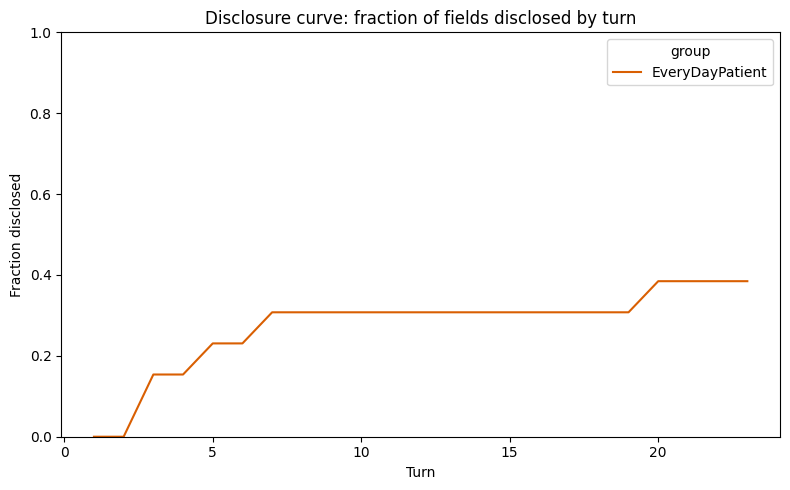

In [14]:
if "time_to_fact" in METRICS:
    curve_df = pd.DataFrame(
        [
            {
                "patient_type": "PatientsWithPersonality",
                "ttf_per_field": ttf_result["ttf_per_field"],
            }
        ]
    )
    plot_disclosure_curve(curve_df, group_col="patient_type", max_turns=len(turns_df))